# Portfolio problem

In [23]:
import math
from pathlib import Path
import cvxpy as cp
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.constants import IN_SAMPLE_TIME_WINDOW, OUT_OF_SAMPLE_TIME_WINDOW
from mis_dro.plot import *

# from matplotlib import rc
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":12})
# rc('text', usetex=True)


In [24]:
# mmc2_dir = Path("/", "Users", "patrick", "Datasets", "misdro", "mmc2")
mmc2_dir = Path("/dcs/pg20/u1508153/datasets/misdro/mmc2")
assert mmc2_dir.exists()
dgp = "DowJones"
returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Assets_Returns", header=None)
index_returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Index_Returns", header=None)

returns_df.iloc[0].var()

0.0013976385717994033

In [25]:
experiment_dir = Path("/dcs/large/u1508153/misdro/mmd_portfolio")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
# NOTE filter out when log_partition_constant G is less than epsilon
# results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]
results_df.tail()

mean_cost  var_cost  \
uuid                                 replication                        
9b4f3563-e1ed-4f7f-9d9a-b8dfa2d4cfba 104           0.000942  0.000180   
                                     105          -0.000556  0.000130   
                                     106          -0.003770  0.001116   
                                     107           0.005829  0.000391   
                                     108           0.001112  0.000611   

                                                                                           solution  \
uuid                                 replication                                                      
9b4f3563-e1ed-4f7f-9d9a-b8dfa2d4cfba 104          [0.003372808169176531, 0.06662281642980689, 0....   
                                     105          [0.03651987183184383, 0.0054394998336925425, 4...   
                                     106          [0.06472122012748621, 0.07114647228851477, 9.1...   
                                     107          [3.566573050592879e-10, 6.954167334558872e-08,...   
                                     108          [0.021808232397390975, 1.8077557228062763e-09,...   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
9b4f3563-e1ed-4f7f-9d9a-b8dfa2d4cfba 104          0.248601         0.000001   
                                     105          0.250534         0.000001   
                                     106          0.249337         0.000001   
                                     107          0.249804         0.000001   
                                     108          0.249183         0.000001   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
9b4f3563-e1ed-4f7f-9d9a-b8dfa2d4cfba 104                0.000020    1.484389   
                                     105                0.000021    1.404370   
                                     106                0.000020    1.471666   
                                     107                0.000020    1.473763   
                                     108                0.000019    1.395585   

                                                  setup_time  \
uuid                                 replication               
9b4f3563-e1ed-4f7f-9d9a-b8dfa2d4cfba 104                 NaN   
                                     105                 NaN   
                                     106                 NaN   
                                     107                 NaN   
                                     108                 NaN   

                                                  log_partition_constant  \
uuid                                 replication                           
9b4f3563-e1ed-4f7f-9d9a-b8dfa2d4cfba 104                             0.0   
                                     105                             0.0   
                                     106                             0.0   
                                     107                             0.0   
                                     108                             0.0   

                                                                                out_of_sample_costs  \
uuid                                 replication                                                      
9b4f3563-e1ed-4f7f-9d9a-b8dfa2d4cfba 104          [0.007997824842976533, -0.027512113212882043, ...   
                                     105          [0.0029095469678470437, 0.007002084156113463, ...   
                                     106          [0.016860182788228397, 0.008446190603225611, -...   
                                     107          [0.05062084733250401, 0.017214053655379098, -0...   
                                     108          [0.016737572431085226, -0.019284148370433563, ...  

In [26]:
experiment_dir = Path("/dcs/large/u1508153/misdro/tiny_kl_portfolio")
assert experiment_dir.exists()
kl_results_df = pd.read_csv(experiment_dir / "results.csv")
# NOTE filter out when log_partition_constant G is less than epsilon
# results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]
# kl_results_df = kl_results_df.loc[kl_results_df["replication"] < 2].set_index(["uuid", "replication"])
results_df = pd.concat([results_df, kl_results_df])
results_df["algorithm"].unique().tolist()

['dro_bas_mmd', 'empirical_mmd', 'kl_dro_bas', 'kl_bdro']

In [27]:
agg_df = get_agg_df(results_df, ["algorithm","dgp", "epsilon", "num_posterior_samples"])
agg_df

/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:303: FutureWarning: The provided callable <function mean at 0x7fe6f8092340> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:303: FutureWarning: The provided callable <function var at 0x7fe6f80925c0> is currently using SeriesGroupBy.var. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "var" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:303: FutureWarning: The provided callable <function mean at 0x7fe6f8092340> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis

out_of_sample_mean  \
algorithm   dgp      epsilon num_posterior_samples                       
dro_bas_mmd DowJones 0.0001  90                               0.003194   
                     0.0005  90                               0.003174   
                     0.0010  90                               0.003031   
                     0.0050  90                               0.003373   
                     0.0100  90                               0.003227   
...                                                                ...   
kl_dro_bas  DowJones 0.0500  1                                0.002581   
                     0.1000  1                                0.002504   
                     0.2000  1                                0.002458   
                     0.5000  1                                0.002420   
                     1.0000  1                                0.002401   

                                                    out_of_sample_mean_of_vars  \
algorithm   dgp      epsilon num_posterior_samples                               
dro_bas_mmd DowJones 0.0001  90                                       0.001668   
                     0.0005  90                                       0.001631   
                     0.0010  90                                       0.001598   
                     0.0050  90                                       0.001170   
                     0.0100  90                                       0.000828   
...                                                                        ...   
kl_dro_bas  DowJones 0.0500  1                                        0.000486   
                     0.1000  1                                        0.000473   
                     0.2000  1                                        0.000467   
                     0.5000  1                                        0.000464   
                     1.0000  1                                        0.000463   

                                                    out_of_sample_var_of_means  \
algorithm   dgp      epsilon num_posterior_samples                               
dro_bas_mmd DowJones 0.0001  90                                       0.000143   
                     0.0005  90                                       0.000142   
                     0.0010  90                                       0.000140   
                     0.0050  90                                       0.000078   
                     0.0100  90                                       0.000054   
...                                                                        ...   
kl_dro_bas  DowJones 0.0500  1                                        0.000030   
                     0.1000  1                                        0.000029   
                     0.2000  1                                        0.000028   
                     0.5000  1                                        0.000028   
                     1.0000  1                                        0.000028   

                                                    mean_solve_time  \
algorithm   dgp      epsilon num_posterior_samples                    
dro_bas_mmd DowJones 0.0001  90                          318.859828   
                     0.0005  90                          296.836373   
                     0.0010  90                          299.084741   
                     0.0050  90                          319.068572   
                     0.0100  90                          282.243468   
...                                                             ...   
kl_dro_bas  DowJones 0.0500  1                             0.011771   
                     0.1000  1                             0.011766   
                     0.2000  1                             0.012064   
                     0.5000  1                             0.011824   
                     1.0000  1                             0.012099   

                               

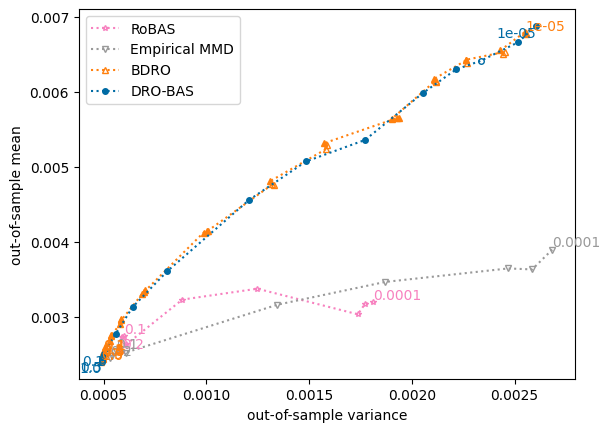

In [28]:
posterior_sr = agg_df.index.get_level_values("num_posterior_samples")
fig, ax = plt.subplots()
NUM_POSTERIOR_SAMPLES = 5
# df = agg_df.loc[(posterior_sr == 1) | (posterior_sr == NUM_POSTERIOR_SAMPLES)]
df = agg_df
# df = df.loc[:,:,0.1:]
df.loc[:, "is_maximise_pareto_front"] = is_maximise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
gb = df.groupby("algorithm")
for algorithm, group_df in gb:
    mean_variance_plot(ax, group_df, is_labelled=True, offset=0, alpha=1.0, **algorithm_style(algorithm), pareto_front_col="is_maximise_pareto_front")
ax.legend()
ax.set_xlabel("out-of-sample variance")
ax.set_ylabel("out-of-sample mean")
# ax.set_xlim(agg_df["out_of_sample_var"].min(), agg_df["out_of_sample_var"].max())
# ax.set_ylim(agg_df["out_of_sample_mean"].min(), agg_df["out_of_sample_mean"].min())
fig.show()

In [29]:
num_time_windows = math.floor((len(returns_df) - IN_SAMPLE_TIME_WINDOW) / OUT_OF_SAMPLE_TIME_WINDOW)
num_stocks = int(len(returns_df.columns))

In [30]:
week_cols = [f"week_{i}" for i in range(OUT_OF_SAMPLE_TIME_WINDOW)]
stock_cols = [f"stock_{i}" for i in range(num_stocks)]
dro_returns = {week: [] for week in week_cols}
for stock in stock_cols:
    dro_returns[stock] = []
dro_returns["uuid"] = []
dro_returns["replication"] = []
for idx, row in results_df[["out_of_sample_costs", "solution"]].iterrows():
    print(idx)
    uuid, replication = idx
    str_cost, str_solution = row["out_of_sample_costs"], row["solution"]
    if str_cost == "[]":
        costs = [np.nan for _ in range(OUT_OF_SAMPLE_TIME_WINDOW)]
    else:
        costs = [float(x) for x in str_cost.strip('[]').split(',')]
    solution = [float(x) for x in str_solution.strip('[]').split(',')]
    dro_returns["uuid"].append(uuid)
    dro_returns["replication"].append(replication)
    for i, week in enumerate(week_cols):
        dro_returns[week].append(costs[i])
    for i, stock in enumerate(stock_cols):
        dro_returns[stock].append(solution[i])

dro_returns_df = pd.DataFrame(dro_returns).set_index(["uuid", "replication"])
dro_returns_df

('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 0)
('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 1)
('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 2)
('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 3)
('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 4)
('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 5)
('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 6)
('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 7)
('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 8)
('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 9)
('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 10)
('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 11)
('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 12)
('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 13)
('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 14)
('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 15)
('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 16)
('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 17)
('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 18)
('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 19)
('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 20)
('51441df2-9498-4092-aeaf-cbe8a57c7c4f', 21)
('51441df2-9498-4092

TypeError: cannot unpack non-iterable int object

In [8]:
# join the dataframes, the sort and groupby
results_df = results_df.join(dro_returns_df)
results_df

mean_cost  var_cost  \
uuid                                 replication                        
1bbd2f9f-5659-47fb-85db-df74063368e0 0             0.009859  0.006167   
                                     1             0.000238  0.001421   
fd75c4a2-4bd9-42f8-85d5-606c94a2b382 0             0.010159  0.001519   
                                     1             0.000301  0.001407   
4bb984e7-cfdc-4860-a86a-afa26ff8b8e5 0             0.005740  0.000478   
                                     1             0.003509  0.000622   
0fccd472-44ca-4005-a0c6-a7cb81e2747b 0             0.004631  0.000192   
                                     1             0.005621  0.000587   
b236e9f3-5bb6-45fc-b378-029d807b0ebb 0             0.003975  0.000206   
                                     1             0.003561  0.000535   
bc95899d-078c-4fb5-868b-3075b78cc9a3 0             0.003341  0.000214   
                                     1             0.004697  0.000478   
0c4d0417-3ed3-4952-8ec7-d32412df70dc 0             0.003914  0.000197   
                                     1             0.004777  0.000549   
e0c22d57-b5f2-430e-a9c4-851eaf6b95ca 0             0.011541  0.003906   
                                     1            -0.001486  0.002031   
02e66fce-9e16-466d-94de-56358451672c 0             0.008769  0.002629   
                                     1             0.004980  0.001149   
adc56997-3050-4681-bcfe-92f5eee3f7b4 0             0.003963  0.000751   
                                     1             0.004307  0.000874   
3b24af41-caa7-4e14-a2bf-c65e3c8377db 0             0.001416  0.000206   
                                     1             0.002617  0.000414   
8a397c49-a2e9-4554-aa32-8edfa882bb40 0             0.002167  0.000186   
                                     1             0.002557  0.000413   
255fea9b-0df4-4efc-b3db-5eaf593f9d44 0             0.002624  0.000189   
                                     1             0.002887  0.000394   
fb6ed04e-176e-4c1a-9c0d-c1d93104b7c6 0             0.002740  0.000181   
                                     1             0.003435  0.000413   

                                                                                           solution  \
uuid                                 replication                                                      
1bbd2f9f-5659-47fb-85db-df74063368e0 0            [7.691347440093576e-10, 1.3473899087520994e-10...   
                                     1            [2.7718869457327517e-09, 3.005703518452282e-09...   
fd75c4a2-4bd9-42f8-85d5-606c94a2b382 0            [0.025169414591981916, 9.649132219723302e-11, ...   
                                     1            [8.352711035719752e-08, 1.301797693455468e-07,...   
4bb984e7-cfdc-4860-a86a-afa26ff8b8e5 0            [0.0663945728932686, 1.0995604928357556e-10, 0...   
                                     1            [3.692165157959478e-08, 0.048127126592024214, ...   
0fccd472-44ca-4005-a0c6-a7cb81e2747b 0            [0.04429208769677609, 0.004777311107531628, 0....   
                                     1            [0.028712825223650613, 0.02475497677254383, 2....   
b236e9f3-5bb6-45fc-b378-029d807b0ebb 0            [0.0423539333980032, 2.3518628193686118e-08, 0...   
                                     1            [0.025053760655616604, 0.01689670641930815, 4....   
bc95899d-078c-4fb5-868b-3075b78cc9a3 0            [0.021332754043393378, 0.02985240583621951, 0....   
                                     1            [0.030198424275004597, 0.02588511440932363, 0....   
0c4d0417-3ed3-4952-8ec7-d32412df70dc 0            [0.04046675850943096, 0.01522202929184883, 0.0...   
                                     1            [0.020004766609771164, 0.026496600043580502, 0...   
e0c22d57-b5f2-430e-a9c4-851eaf6b95ca 0            [1.984564561240952e-09, 1.4269696425508006e-09...   
                                     1            [4.151703196608293e-08, 2.5031687695534595e-08...   
02e66

In [9]:
results_df = results_df.loc[(results_df["num_posterior_samples"] == NUM_POSTERIOR_SAMPLES) | (results_df["num_posterior_samples"] == 1)]
gb = results_df.groupby(["algorithm", "epsilon", "num_posterior_samples"])

In [10]:
for (algorithm, epsilon, num_posterior_samples), group_df in gb:
    dro_bas_returns = group_df[week_cols].values.flatten()
    print(algorithm, epsilon, np.sum(dro_bas_returns))

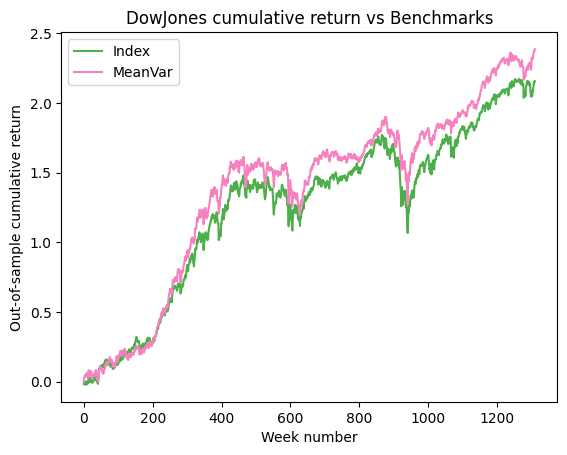

In [11]:
# dro_bas_returns = solution_returns.flatten()
bdro_labelled = False
dro_bas_labelled = False
for (algorithm, epsilon, num_posterior_samples), group_df in gb:
    dro_returns = group_df[week_cols].values.flatten()
    if not dro_bas_labelled and algorithm == "kl_dro_bas":
        label = algorithm
        dro_bas_labelled = True
    elif not bdro_labelled and algorithm == "kl_bdro":
        label = algorithm
        bdro_labelled = True
    else:
        label='_nolegend_'
    plt.plot(np.cumsum(dro_returns), label=label, alpha=0.3, color=AlgorithmColor[algorithm].value)
CB_color_cycle = ['#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
plt.plot(np.cumsum(index_returns_df.iloc[IN_SAMPLE_TIME_WINDOW:].values), label="Index", color=CB_color_cycle[0])
# for baseline_model in ["CZeSD", "KP_SSD", "L_SSD", "LR_ASSD", "MeanVar", "RMZ_SSD"]:

for i, baseline_model in enumerate(["MeanVar"]):
    baseline_portfolio_txt = mmc2_dir / "Solutions" / dgp / f"OptPortfolios_{baseline_model}_{dgp}.txt"
    baseline_portfolio = np.loadtxt(baseline_portfolio_txt).T[:num_time_windows, :]
    baseline_returns_txt = mmc2_dir / "Solutions" / dgp / f"OutofSamplePortReturns_{baseline_model}_{dgp}_List.txt" 
    baseline_returns = np.loadtxt(baseline_returns_txt)
    plt.plot(np.cumsum(baseline_returns), label=baseline_model, color=CB_color_cycle[i+1])

plt.xlabel("Week number")
plt.ylabel("Out-of-sample cumulative return")
plt.title(dgp + r" cumulative return vs Benchmarks")
plt.legend()
plt.show()

In [12]:

for (algorithm, epsilon), group_df in results_df.groupby(["algorithm", "epsilon"]):
    # print(algorithm, epsilon, np.mean(group_df[stock_cols].values), np.var(group_df[stock_cols].values))
    print(algorithm, epsilon, np.mean(group_df[stock_cols].values, axis=0))